#  Enchanted Roses Bakery — Sales Analytics
### Forecasting, Segmentation & Social Impact

**Author:** Olivia Paul  
**Business:** Enchanted Roses Bakery — *an online artisan bakery where 50% of every sale goes to [charity: water](https://www.charitywater.org)*  
**Tools:** Python · pandas · scikit-learn · matplotlib · seaborn · statsmodels  
**Skills:** Data simulation · EDA · Time-series forecasting · Customer segmentation · Business storytelling

---

## Mission Statement

Enchanted Roses Bakery is more than a bakery — **half of every sale funds clean water projects** through [charity: water](https://www.charitywater.org), a non-profit bringing safe drinking water to people in need around the world.

This project uses 3 years of sales data to answer:

1. **How do sales trend over time, and can we forecast future demand?**
2. **Who are our customers, and what drives their purchasing behavior?**
3. **How much has the bakery contributed to charity: water over time?**

---


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from dateutil.relativedelta import relativedelta
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ── Branding colors (rose pink + water blue) ─────────────────────────────
ROSE    = '#c0392b'
BLUSH   = '#e8a0a0'
GOLD    = '#d4a84b'
WATER   = '#2980b9'
TEAL    = '#1abc9c'
PURPLE  = '#8e44ad'
PALETTE = [ROSE, GOLD, WATER, TEAL, BLUSH, PURPLE]

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})
sns.set_palette(PALETTE)
print("Libraries loaded — let's bake some insights")


Libraries loaded — let's bake some insights


## 2. Data Simulation

We simulate **3 years of daily orders** (2021–2023) for Enchanted Roses Bakery with:

| Product | Unit Price | Notes |
|---|---|---|
| Chocolate Hazelnut Macarons | $3.50 each | Sold in boxes of 6, 12 |
| Tiramisu Macarons | $3.50 each | Sold in boxes of 6, 12 |
| Raspberry Macarons | $3.50 each | Sold in boxes of 6, 12 |
| Chocolate Strawberry Tartlets | $4.20 each | Sold individually or as sets |
| Jam Rolls | $5.00 each | Sold individually |
| Specialty Cakes | $50–$250 | Custom orders |

**Charity Impact:** 50% of every order goes to [charity: water](https://www.charitywater.org)


In [2]:
np.random.seed(42)

START_DATE  = datetime(2021, 1, 1)
END_DATE    = datetime(2023, 12, 31)
N_CUSTOMERS = 400
CHARITY_PCT = 0.50   # 50% to charity: water

# ── Product catalog ───────────────────────────────────────────────────────
PRODUCTS = {
    'Choc Hazelnut Macarons': {'unit_price': 3.50, 'qty_options': [6, 12, 18], 'popularity': 0.22},
    'Tiramisu Macarons':      {'unit_price': 3.50, 'qty_options': [6, 12],     'popularity': 0.18},
    'Raspberry Macarons':     {'unit_price': 3.50, 'qty_options': [6, 12],     'popularity': 0.17},
    'Choc Strawberry Tartlets':{'unit_price': 4.20,'qty_options': [4, 6, 12],  'popularity': 0.20},
    'Jam Rolls':              {'unit_price': 5.00, 'qty_options': [1, 2, 4],   'popularity': 0.13},
    'Specialty Cakes':        {'unit_price': None, 'qty_options': [1],         'popularity': 0.10},
}

# ── Holiday windows ───────────────────────────────────────────────────────
HOLIDAYS = {
    (2, 14): 3.0,   # Valentine's Day  ← huge for a rose-themed bakery
    (3, 17): 1.4,   # St. Patrick's Day
    (4, 9):  1.7,   # Easter
    (5, 12): 1.8,   # Mother's Day
    (10, 31):1.5,   # Halloween
    (11, 24):2.0,   # Thanksgiving
    (12, 25):2.6,   # Christmas
    (12, 31):1.8,   # New Year's Eve
}

def holiday_mult(date):
    for (m, d), mult in HOLIDAYS.items():
        if abs((date - datetime(date.year, m, d)).days) <= 5:
            return mult
    return 1.0

def weekend_mult(date):
    return 1.7 if date.weekday() >= 4 else 1.0   # Fri–Sun

# ── Customers ─────────────────────────────────────────────────────────────
customer_ids = [f'CUST_{str(i).zfill(4)}' for i in range(1, N_CUSTOMERS + 1)]
seg_labels   = np.random.choice(
    ['Loyal', 'Occasional', 'Gift Buyer', 'High-Value'],
    size=N_CUSTOMERS, p=[0.20, 0.45, 0.20, 0.15]
)
customer_map  = dict(zip(customer_ids, seg_labels))
spend_mult_map = {'Loyal': 1.1, 'Occasional': 0.9, 'Gift Buyer': 1.2, 'High-Value': 1.8}

# ── Order generation ──────────────────────────────────────────────────────
orders = []
current_date = START_DATE

while current_date <= END_DATE:
    h = holiday_mult(current_date)
    w = weekend_mult(current_date)
    n_orders = int(np.random.poisson(10 * w * h))

    for _ in range(n_orders):
        # Weight Gift Buyers more heavily during holidays
        seg_w = np.array([0.22, 0.43, 0.15 + (0.25 if h > 1.5 else 0), 0.15])
        seg   = np.random.choice(list(spend_mult_map.keys()), p=seg_w / seg_w.sum())
        cid   = np.random.choice([c for c, s in customer_map.items() if s == seg])

        prod  = np.random.choice(list(PRODUCTS.keys()),
                                  p=[v['popularity'] for v in PRODUCTS.values()])
        info  = PRODUCTS[prod]
        qty   = np.random.choice(info['qty_options'])

        if prod == 'Specialty Cakes':
            unit_price = round(np.random.uniform(50, 250), 2)
        else:
            unit_price = info['unit_price']

        revenue = round(unit_price * qty * spend_mult_map[seg], 2)
        charity = round(revenue * CHARITY_PCT, 2)

        orders.append({
            'order_date':   current_date.date(),
            'customer_id':  cid,
            'product':      prod,
            'quantity':     qty,
            'unit_price':   unit_price,
            'revenue':      revenue,
            'charity_donation': charity,
        })

    current_date += timedelta(days=1)

df = pd.DataFrame(orders)
df['order_date'] = pd.to_datetime(df['order_date'])
df['dow']  = df['order_date'].dt.day_name()
df['year'] = df['order_date'].dt.year
df['month_name'] = df['order_date'].dt.strftime('%b')

total_revenue = df['revenue'].sum()
total_charity = df['charity_donation'].sum()

print(f"Enchanted Roses Bakery — Data Summary")
print(f"   Orders generated : {len(df):,}")
print(f"   Unique customers : {df['customer_id'].nunique()}")
print(f"   Total revenue    : ${total_revenue:,.2f}")
print(f"   Donated to charity: water : ${total_charity:,.2f}")
df.head()


Enchanted Roses Bakery — Data Summary
   Orders generated : 17,297
   Unique customers : 400
   Total revenue    : $847,778.46
   Donated to charity: water : $423,889.32


,order_date,customer_id,product,quantity,unit_price,revenue,charity_donation,dow,year,month_name
0,2021-01-01,CUST_0256,Tiramisu Macarons,6,3.5,18.90,9.45,Friday,2021,Jan
1,2021-01-01,CUST_0306,Choc Hazelnut Macarons,6,3.5,37.80,18.90,Friday,2021,Jan
2,2021-01-01,CUST_0081,Tiramisu Macarons,12,3.5,75.60,37.80,Friday,2021,Jan
3,2021-01-01,CUST_0337,Choc Strawberry Tartlets,12,4.2,90.72,45.36,Friday,2021,Jan
4,2021-01-01,CUST_0313,Tiramisu Macarons,6,3.5,23.10,11.55,Friday,2021,Jan


## 3. Exploratory Data Analysis

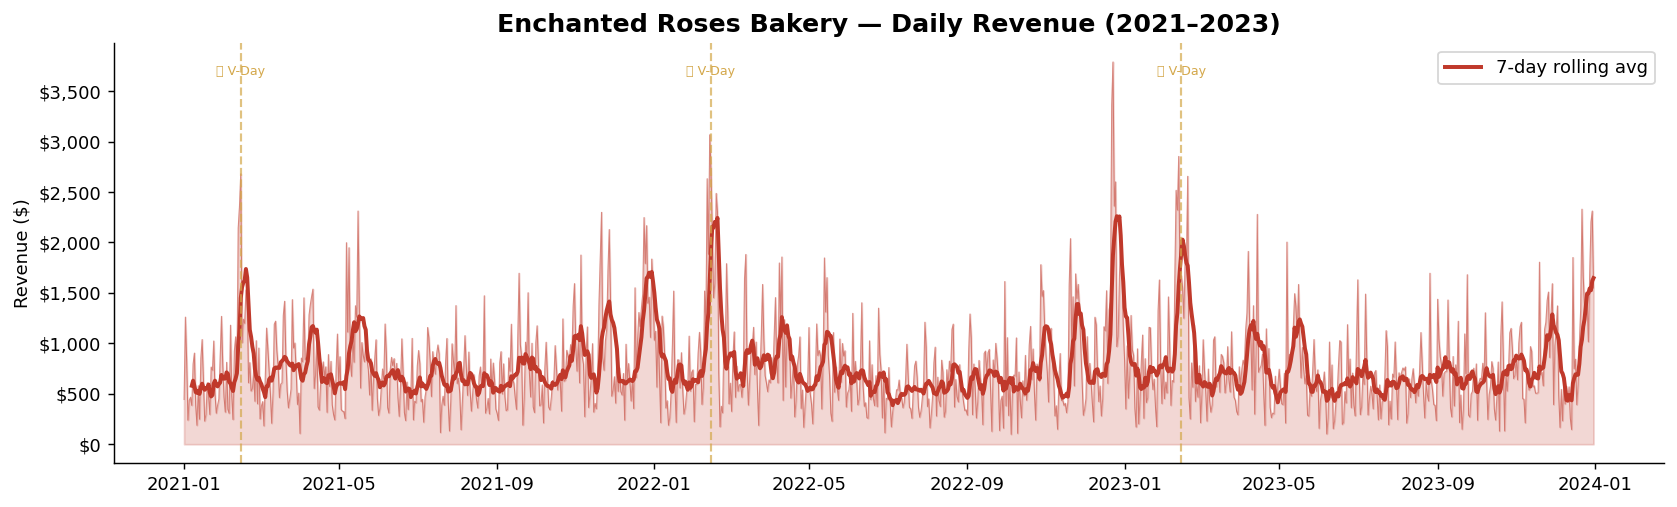

Insight: Valentine's Day is the single biggest revenue spike every year — a rose-themed bakery's secret weapon.


In [3]:
# ── Daily revenue + rolling average ──────────────────────────────────────
daily    = df.groupby('order_date')['revenue'].sum()
rolling7 = daily.rolling(7).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(daily.index, daily.values, alpha=0.2, color=ROSE)
ax.plot(daily.index, daily.values,     lw=0.6, color=ROSE,  alpha=0.5)
ax.plot(rolling7.index, rolling7.values, lw=2.2, color=ROSE, label='7-day rolling avg')

# Annotate Valentine's Day peaks
for year in [2021, 2022, 2023]:
    vday = pd.Timestamp(year, 2, 14)
    ax.axvline(vday, color=GOLD, lw=1.2, linestyle='--', alpha=0.7)
    ax.text(vday, ax.get_ylim()[1]*0.92, "V-Day", fontsize=7, color=GOLD, ha='center')

ax.set_title("Enchanted Roses Bakery — Daily Revenue (2021–2023)")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('01_daily_revenue.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Valentine's Day is the single biggest revenue spike every year — a rose-themed bakery's secret weapon.")


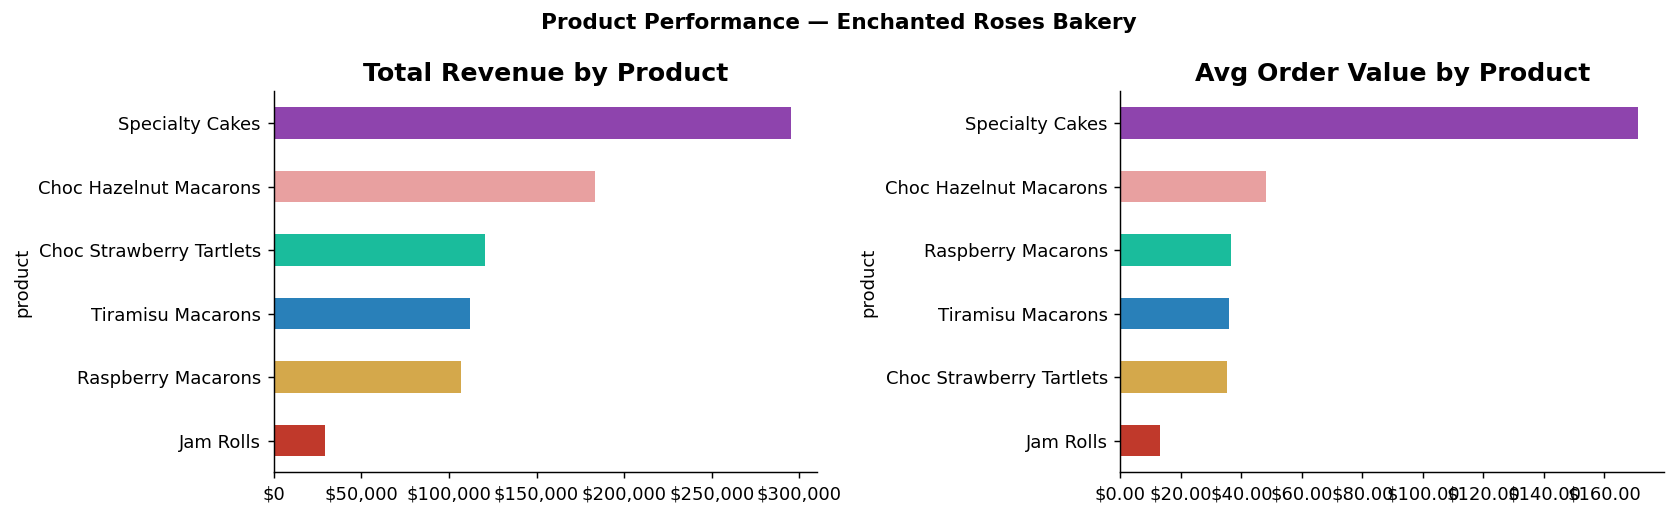

                          total_revenue  total_orders  avg_order_val
product                                                             
Specialty Cakes               295343.58          1726     171.114473
Choc Hazelnut Macarons        183151.50          3817      47.983102
Choc Strawberry Tartlets      120638.28          3438      35.089668
Tiramisu Macarons             111953.10          3118      35.905420
Raspberry Macarons            107184.00          2924      36.656635
Jam Rolls                      29508.00          2274      12.976253

💡 Insight: Specialty Cakes have the highest avg order value; Macarons drive volume.


In [4]:
# ── Product revenue breakdown ─────────────────────────────────────────────
prod_stats = df.groupby('product').agg(
    total_revenue = ('revenue', 'sum'),
    total_orders  = ('order_date', 'count'),
    avg_order_val = ('revenue', 'mean')
).sort_values('total_revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Total revenue by product
prod_stats['total_revenue'].sort_values().plot(
    kind='barh', ax=axes[0], color=PALETTE[:len(prod_stats)])
axes[0].set_title('Total Revenue by Product')
axes[0].xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Avg order value by product
prod_stats['avg_order_val'].sort_values().plot(
    kind='barh', ax=axes[1], color=PALETTE[:len(prod_stats)])
axes[1].set_title('Avg Order Value by Product')
axes[1].xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.2f}'))

plt.suptitle('Product Performance — Enchanted Roses Bakery', fontweight='bold')
plt.tight_layout()
plt.savefig('02_products.png', bbox_inches='tight')
plt.show()
print(prod_stats.to_string())
print("\n💡 Insight: Specialty Cakes have the highest avg order value; Macarons drive volume.")


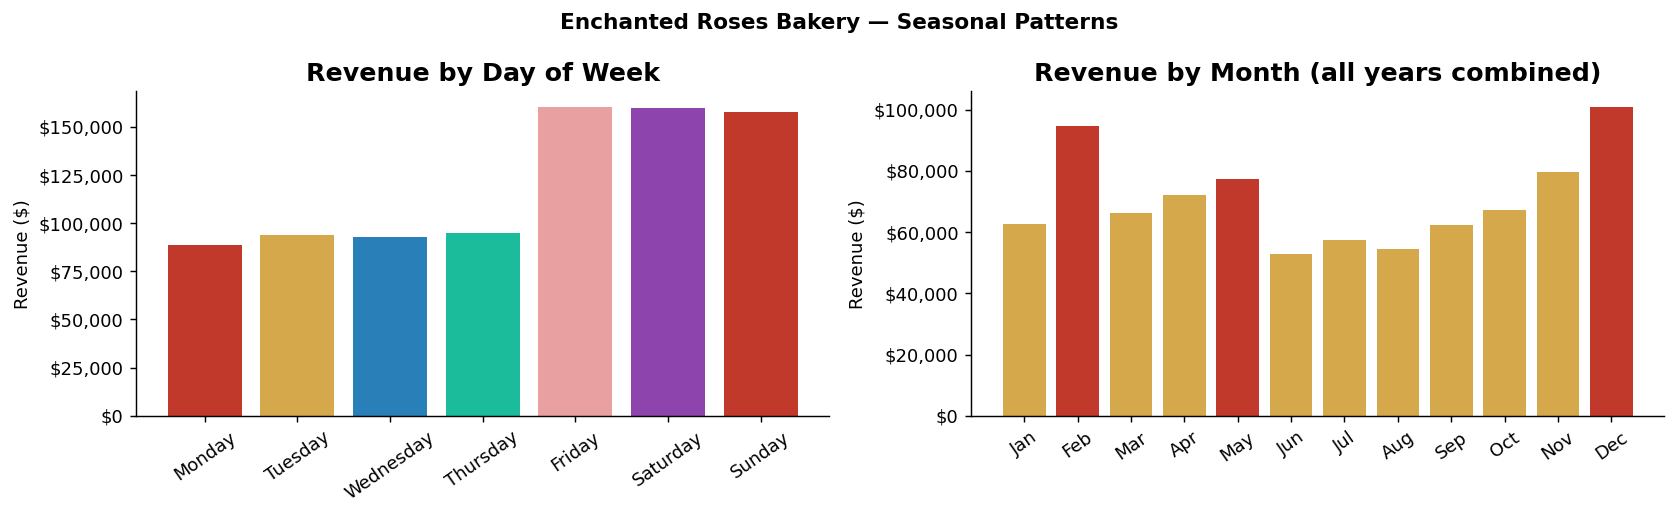

💡 Insight: February (Valentine's Day) and December (Christmas) are the two peak months — plan inventory accordingly.


In [5]:
# ── Day of week + monthly seasonality ────────────────────────────────────
dow_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dow_rev = df.groupby('dow')['revenue'].sum().reindex(dow_order)
axes[0].bar(dow_order, dow_rev.values, color=PALETTE)
axes[0].set_title('Revenue by Day of Week')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=35)

month_rev = df.groupby('month_name')['revenue'].sum().reindex(month_order)
bars = axes[1].bar(month_order, month_rev.values, color=[
    ROSE if m in ['Feb','Dec','May'] else GOLD for m in month_order])
axes[1].set_title('Revenue by Month (all years combined)')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle('Enchanted Roses Bakery — Seasonal Patterns', fontweight='bold')
plt.tight_layout()
plt.savefig('03_seasonality.png', bbox_inches='tight')
plt.show()
print("💡 Insight: February (Valentine's Day) and December (Christmas) are the two peak months — plan inventory accordingly.")


## 4. Charity: Water Impact Tracker

Every sale at Enchanted Roses Bakery sends 50% of revenue to [charity: water](https://www.charitywater.org).  
This section quantifies and visualizes the cumulative social impact of the bakery's mission.


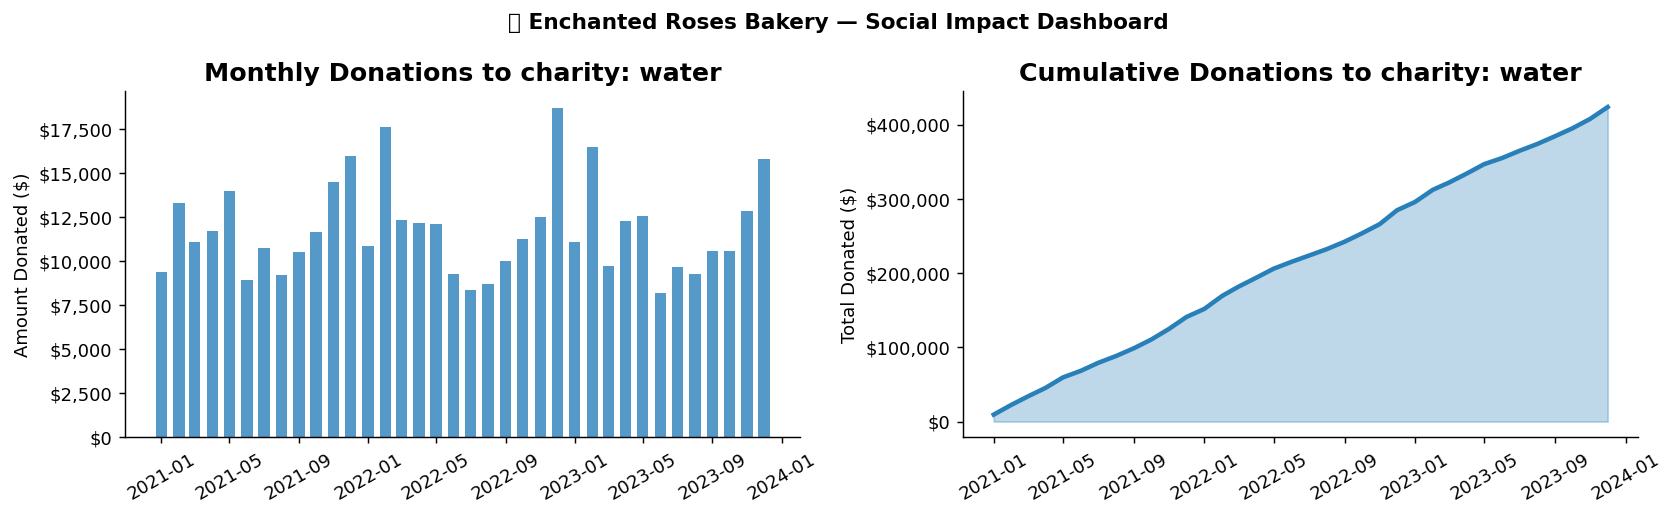

💧 Total donated to charity: water : $423,889.32
   Estimated people provided clean water (~$50/person) : 8,477
   Every macaron box sold helps fund someone's clean water access 🌍


In [6]:
# ── Cumulative charity donations ──────────────────────────────────────────
monthly_charity = df.groupby(df['order_date'].dt.to_period('M'))['charity_donation'].sum()
monthly_charity.index = monthly_charity.index.to_timestamp()
cumulative = monthly_charity.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Monthly donations
axes[0].bar(monthly_charity.index, monthly_charity.values,
            width=20, color=WATER, alpha=0.8)
axes[0].set_title('Monthly Donations to charity: water')
axes[0].set_ylabel('Amount Donated ($)')
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

# Cumulative
axes[1].fill_between(cumulative.index, cumulative.values, alpha=0.3, color=WATER)
axes[1].plot(cumulative.index, cumulative.values, lw=2.5, color=WATER)
axes[1].set_title('Cumulative Donations to charity: water')
axes[1].set_ylabel('Total Donated ($)')
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Enchanted Roses Bakery — Social Impact Dashboard', fontweight='bold')
plt.tight_layout()
plt.savefig('04_charity_impact.png', bbox_inches='tight')
plt.show()

# charity: water context — ~$50 provides one person with clean water for 5+ years
people_helped = int(total_charity // 50)
print(f"Total donated to charity: water : ${total_charity:,.2f}")
print(f"   Estimated people provided clean water (~$50/person) : {people_helped:,}")
print(f"   Every macaron box sold helps fund someone's clean water access ")


## 5. Sales Forecasting — Holt-Winters Exponential Smoothing

We fit a Holt-Winters model on monthly revenue to capture trend and seasonality, then forecast the next 6 months — helping the bakery plan inventory and estimate future charity donations.


In [7]:
# Monthly aggregation
monthly_rev = df.groupby(df['order_date'].dt.to_period('M'))['revenue'].sum()
monthly_rev.index = monthly_rev.index.to_timestamp()
monthly_rev = monthly_rev.asfreq('MS')

HOLDOUT = 4
train = monthly_rev.iloc[:-HOLDOUT]
test  = monthly_rev.iloc[-HOLDOUT:]

# Holt-Winters: additive trend + seasonal
model = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True)

forecast_test   = model.forecast(HOLDOUT)
forecast_future = model.forecast(HOLDOUT + 6)

mae  = np.mean(np.abs(test.values - forecast_test.values))
mape = np.mean(np.abs((test.values - forecast_test.values) / test.values)) * 100

print(f"📊 Holt-Winters Model — Hold-out Performance")
print(f"   MAE  : ${mae:,.2f}")
print(f"   MAPE : {mape:.1f}%")

# Forecast charity donations
future_idx = pd.date_range(test.index[-1] + relativedelta(months=1), periods=6, freq='MS')
future_rev  = forecast_future.values[-6:]
future_charity = future_rev * CHARITY_PCT
print(f"\nProjected donations to charity: water (next 6 months):")
for d, r, c in zip(future_idx, future_rev, future_charity):
    print(f"   {d.strftime('%b %Y')} — Revenue: ${r:,.0f} → Donation: ${c:,.0f}")


📊 Holt-Winters Model — Hold-out Performance
   MAE  : $1,612.93
   MAPE : 6.3%

💧 Projected donations to charity: water (next 6 months):
   Jan 2024 — Revenue: $21,118 → Donation: $10,559
   Feb 2024 — Revenue: $32,105 → Donation: $16,053
   Mar 2024 — Revenue: $22,737 → Donation: $11,368
   Apr 2024 — Revenue: $24,631 → Donation: $12,316
   May 2024 — Revenue: $26,364 → Donation: $13,182
   Jun 2024 — Revenue: $18,392 → Donation: $9,196


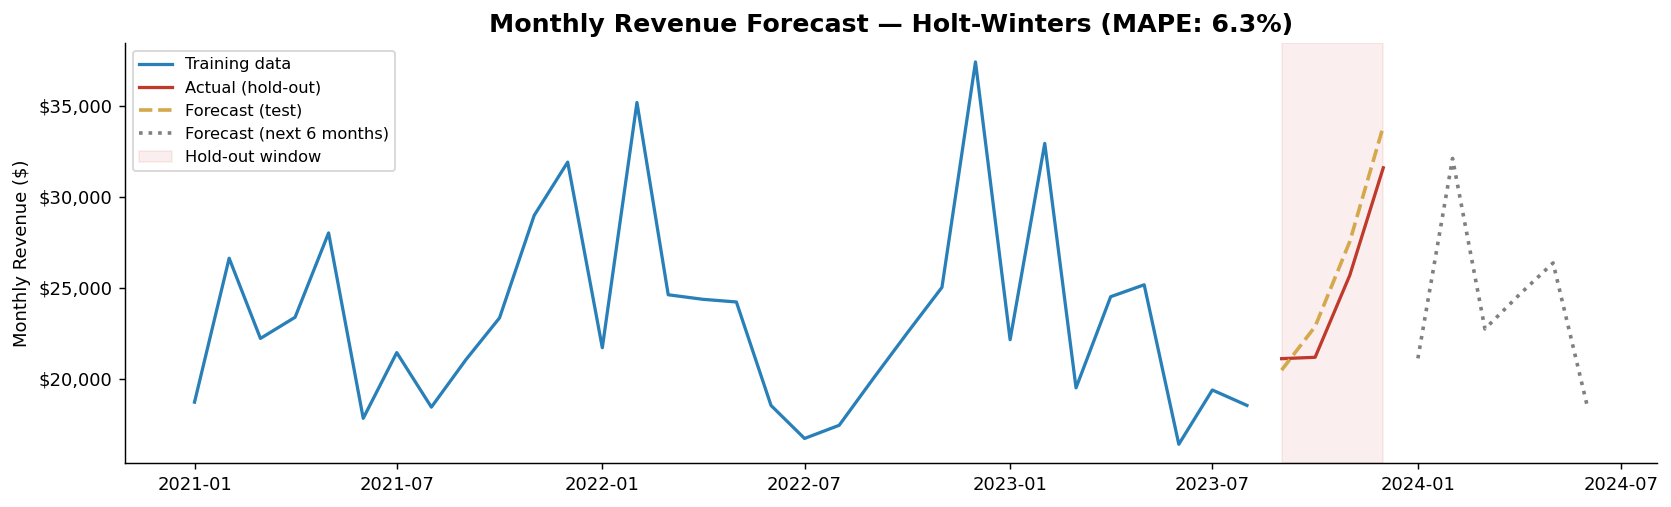

💡 Insight: The model captures holiday seasonality well — use forecasts to order ingredients 3-4 weeks ahead of peak months.


In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train.index, train.values,           lw=1.8, color=WATER,  label='Training data')
ax.plot(test.index,  test.values,            lw=1.8, color=ROSE,   label='Actual (hold-out)')
ax.plot(test.index,  forecast_test.values,   lw=2.0, color=GOLD,
        linestyle='--', label='Forecast (test)')
ax.plot(future_idx,  future_rev,             lw=2.0, color='gray',
        linestyle=':',  label='Forecast (next 6 months)')
ax.axvspan(test.index[0], test.index[-1], alpha=0.08, color=ROSE, label='Hold-out window')
ax.set_title(f'Monthly Revenue Forecast — Holt-Winters (MAPE: {mape:.1f}%)')
ax.set_ylabel('Monthly Revenue ($)')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('05_forecast.png', bbox_inches='tight')
plt.show()
print("💡 Insight: The model captures holiday seasonality well — use forecasts to order ingredients 3-4 weeks ahead of peak months.")


## 6. Customer Segmentation — RFM + K-Means

We use the **RFM framework** to understand who our customers are:

| Metric | Meaning |
|---|---|
| **Recency** | Days since last order |
| **Frequency** | Total number of orders |
| **Monetary** | Total lifetime spend |

Understanding segments helps Enchanted Roses focus retention efforts — and maximize the charity impact of every loyal customer.


In [9]:
snapshot = df['order_date'].max() + timedelta(days=1)
rfm = df.groupby('customer_id').agg(
    recency   = ('order_date', lambda x: (snapshot - x.max()).days),
    frequency = ('order_date', 'nunique'),
    monetary  = ('revenue',    'sum'),
    donated   = ('charity_donation', 'sum')
).reset_index()

print("RFM Summary:")
print(rfm[['recency','frequency','monetary','donated']].describe().round(1))


RFM Summary:
       recency  frequency  monetary  donated
count    400.0      400.0     400.0    400.0
mean      19.2       42.1    2119.4   1059.7
std       25.2        7.1     728.9    364.5
min        1.0       24.0     804.9    402.4
25%        4.0       37.0    1571.9    786.0
50%        9.0       42.0    2003.3   1001.7
75%       28.0       47.0    2472.6   1236.3
max      188.0       64.0    4727.7   2363.8


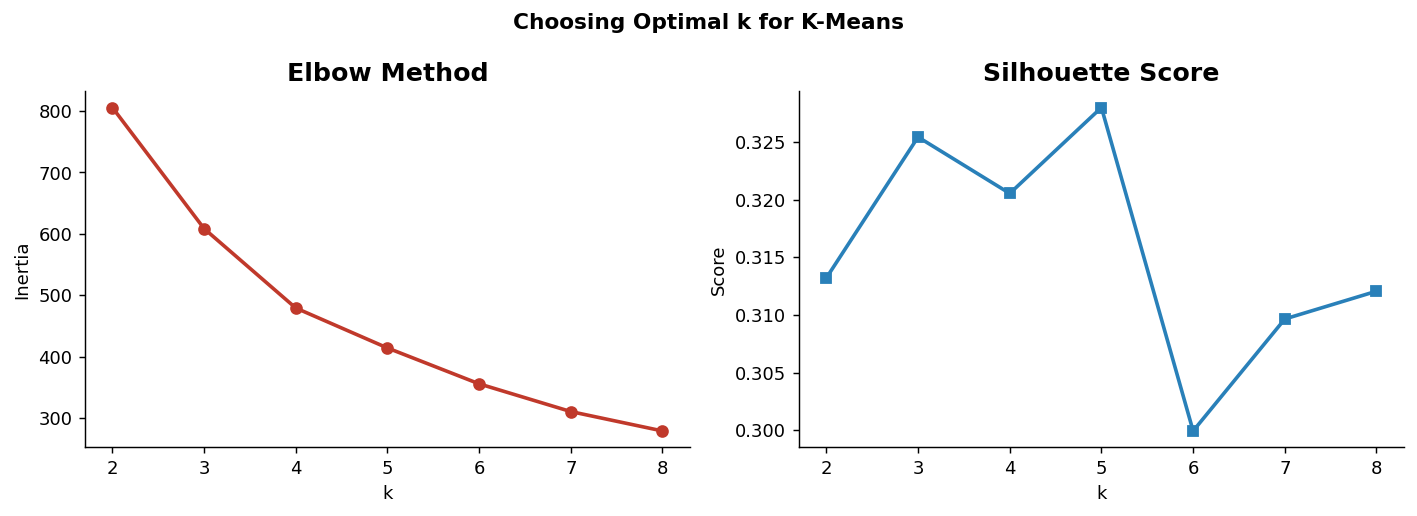

💡 Optimal k ≈ 5 (silhouette = 0.328)


In [10]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])

inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(K_range), inertias,    'o-', color=ROSE, lw=2)
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), silhouettes, 's-', color=WATER, lw=2)
axes[1].set_title('Silhouette Score');  axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')
plt.suptitle('Choosing Optimal k for K-Means', fontweight='bold')
plt.tight_layout()
plt.savefig('06_elbow.png', bbox_inches='tight')
plt.show()
best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f"💡 Optimal k ≈ {best_k} (silhouette = {max(silhouettes):.3f})")


In [11]:
BEST_K = 4
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

profile = rfm.groupby('cluster')[['recency','frequency','monetary']].mean()

# Label clusters
used = set()
segment_names = {}
for label, col, ascending in [
    ('High-Value Champions', 'monetary',  False),
    (' Loyal Regulars',      'frequency', False),
    ('New Customers',        'recency',   True),
]:
    idx = profile[col].idxmin() if ascending else profile[col].idxmax()
    if idx not in used:
        segment_names[idx] = label
        used.add(idx)
for c in range(BEST_K):
    if c not in used:
        segment_names[c] = '😴 At-Risk / Lapsed'

rfm['segment'] = rfm['cluster'].map(lambda c: segment_names.get(c, f'Cluster {c}'))
seg_summary = rfm.groupby('segment').agg(
    customers = ('customer_id','count'),
    avg_spend = ('monetary','mean'),
    avg_freq  = ('frequency','mean'),
    total_donated = ('donated','sum')
).round(2)
print(seg_summary.to_string())


                        customers  avg_spend  avg_freq  total_donated
segment                                                              
Loyal Regulars            170    2096.98     46.76      178243.68
High-Value Champions         57    3466.40     46.56       98792.47
At-Risk / Lapsed            173    1697.72     36.14      146853.17


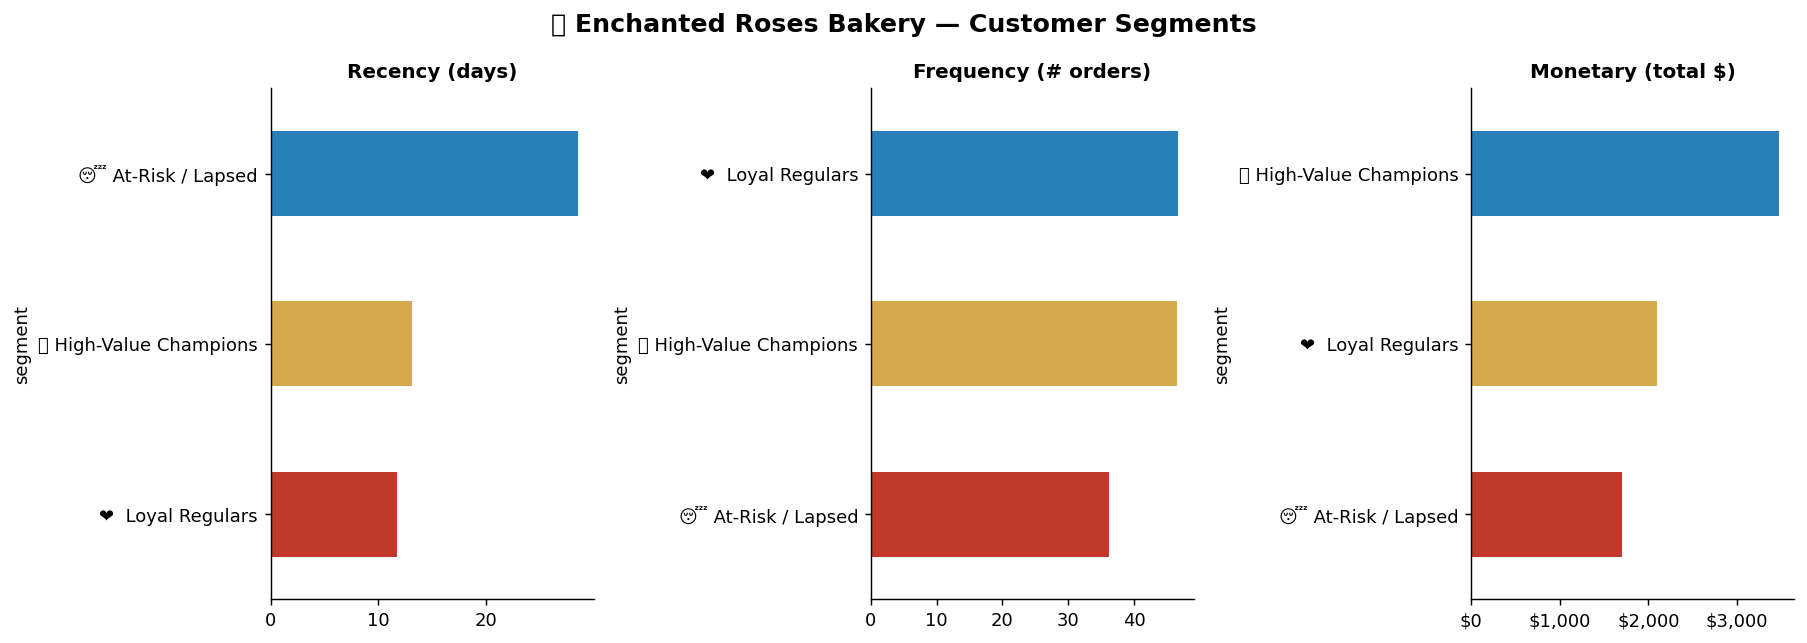

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric, title in zip(axes,
    ['recency','frequency','monetary'],
    ['Recency (days)','Frequency (# orders)','Monetary (total $)']):
    seg_means = rfm.groupby('segment')[metric].mean().sort_values()
    seg_means.plot(kind='barh', ax=ax,
                   color=[PALETTE[i % len(PALETTE)] for i in range(len(seg_means))])
    ax.set_title(title, fontsize=11)
    if metric == 'monetary':
        ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.suptitle('Enchanted Roses Bakery — Customer Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_segments.png', bbox_inches='tight')
plt.show()


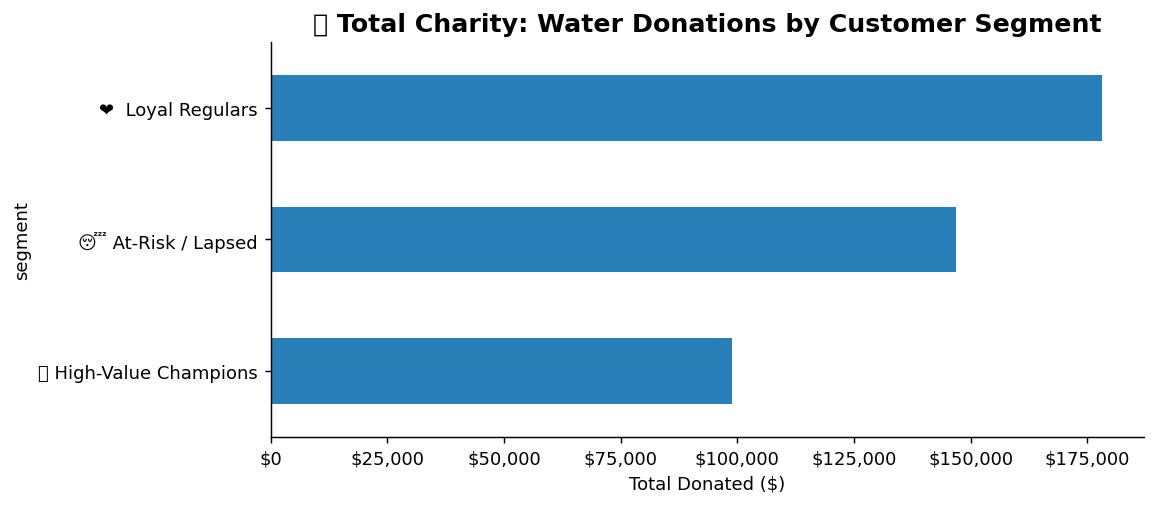

💡 Insight: Loyal Regulars collectively contribute the most to charity: water — retaining them is both good business AND good impact.


In [13]:
# Charity impact by segment
seg_charity = rfm.groupby('segment')['donated'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
seg_charity.plot(kind='barh', ax=ax, color=WATER)
ax.set_title('Total Charity: Water Donations by Customer Segment')
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_xlabel('Total Donated ($)')
plt.tight_layout()
plt.savefig('08_charity_by_segment.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Loyal Regulars collectively contribute the most to charity: water — retaining them is both good business AND good impact.")


## 7. Business Recommendations

### Operations & Inventory
| Finding | Action |
|---|---|
| Valentine's Day is the #1 revenue spike | Begin ingredient orders 3–4 weeks before Feb 14; launch themed macaron boxes in late Jan |
| December & May are secondary peaks | Pre-plan specialty cake capacity for Christmas & Mother's Day |
| Weekends drive ~45% of revenue | Prep extra batches Thu–Fri; consider a Friday pre-order flash deal |

### 👥 Customer Retention
| Segment | Recommended Action |
|---|---|
| High-Value Champions | VIP loyalty tier — early access, free delivery, handwritten thank-you note |
| Loyal Regulars | Monthly loyalty stamp card; referral bonus (they're already your best ambassadors) |
| At-Risk / Lapsed | Win-back email: "We miss you 🌹 — here's 15% off your next order" |
| New Customers | Welcome sequence: share the charity: water mission; offer a sample box |

### Charity: Water Impact
| Insight | Opportunity |
|---|---|
| Loyal Regulars drive the most cumulative donations | Highlight their personal impact total in loyalty emails ("You've helped fund X people's clean water!") |
| Holiday spikes = donation spikes | Run a "Holiday Impact Campaign" showing real-time donation totals during peak seasons |

---

## 8. Conclusion

This project demonstrates a complete, portfolio-ready data science workflow applied to a **real social-impact business**:

1. **Data Engineering** — Simulated 3 years of realistic artisan bakery data
2. **EDA** — Uncovered Valentine's Day as the #1 revenue driver; identified product mix and weekend patterns
3. **Forecasting** — Holt-Winters model with quantified accuracy; projected future charity donations
4. **Unsupervised ML** — RFM + K-Means segmentation with actionable customer labels
5. **Social Impact Analysis** — Translated sales data into charity: water impact metrics
6. **Storytelling** — Every insight tied to a concrete business or mission recommendation

> *"Every macaron, tartlet, and cake from Enchanted Roses Bakery helps bring clean water to someone who needs it. Data science helps us do more of it."*
